# Americas TechGuard — Período 8
## Integração LoRa/Meshtastic, JSON e Alertas Ambientais — Blumenau / Vale do Itajaí

**Rosemeri Borges** — UniSENAI/SC, Campus Florianópolis  
**Trilha B** (software-only / simulação), com firmware ESP32 pronto para a Trilha A.

Cadeia completa executada aqui:

`chuva e vazão observadas → ATG-ENV 1.0 (JSON) → validação → risco (escada oficial AlertaBlu) → codec ATG-C1 (23 B) → malha Meshtastic → gateway → MQTT/JSON → alerta no celular`

Roda no Colab, sem GPU e sem chave de API.

## 0. Setup

In [1]:
!pip -q install "jsonschema>=4.20"
!git clone -q https://github.com/RoseBorges44/Americas-TechGuard-Semana8.git

In [2]:
%cd /content/Americas-TechGuard-Semana8
import sys
sys.path.insert(0, "src")
!ls

/content/Americas-TechGuard-Semana8
examples  LICENSE    README.md	       scripts	tests
hardware  notebooks  requirements.txt  src


## 1. Testes automatizados

Antes de qualquer resultado, o código precisa passar por testes: schema, codec, risco, LoRa, malha, MQTT.

In [3]:
!python -m pytest -q

..............................                                           [100%]
30 passed in 3.71s


## 2. Coleta dos dados REAIS

Duas APIs abertas, sem chave:

- **Open-Meteo Archive (ERA5-Land)** → chuva horária observada nas 4 coordenadas reais dos nós.
- **Open-Meteo Flood (GloFAS v4, Copernicus EMS)** → vazão diária do rio na régua de Blumenau.

A janela do evento é escolhida **automaticamente** (maior vazão do período consultado) — sem cherry-picking.

In [4]:
!python scripts/00_fetch_data.py --from 2023-01-01 --to 2025-12-31

[1/3] GloFAS: localizando a celula do canal principal do Itajai-Acu
      (5 km de resolucao: a celula mais proxima da regua pode ser
       um afluente - varremos uma grade 3x3 e pegamos a maior vazao)
      celula GloFAS escolhida: (-26.9187, -48.9665)  (vazao media 361.8 m3/s)

[2/3] GloFAS (Copernicus EMS): vazao diaria 2023-01-01 .. 2025-12-31
      pico = 3213 m3/s em 2023-10-09

[3/3] janela do evento selecionada automaticamente: 2023-10-04 .. 2023-10-14
      arquivos gravados em /content/Americas-TechGuard-Semana8/data/raw
        - discharge_glofas_climatology.csv (343.2 kB)
        - discharge_glofas_daily.csv (0.4 kB)
        - event_window.json (0.2 kB)
        - rain_era5_climatology.csv (14333.9 kB)
        - rain_era5_hourly.csv (72.0 kB)
        - rating_curve.json (0.8 kB)
        - river_hourly_derived.csv (11.7 kB)

Proximo passo:
  python scripts/01_run_pipeline.py --start 2023-10-04 --end 2023-10-14


### 2.1 Vazão → cota: uma aproximação declarada

O GloFAS entrega **vazão**, não **cota**. Não existe curva-chave oficial pública da estação.
Em vez de inventar uma, mapeio **percentis da climatologia GloFAS (1994–hoje)** sobre a
**escada oficial de cotas do AlertaBlu**:

| percentil | cota | estágio oficial |
|---|---|---|
| p50   | 1,2 m | Normalidade |
| p90   | 3,0 m | limiar de Observação |
| p97   | 4,0 m | limiar de Atenção |
| p99,3 | 6,0 m | limiar de **Alerta** |
| p99,9 | 8,0 m | limiar de **Alerta Máximo** |

**Isso não é uma curva-chave.** É uma aproximação monotônica, declarada aqui, no código e no `metrics.json`.

In [5]:
import json

rating = json.load(open("data/raw/rating_curve.json"))
for a in rating["anchors"]:
    print(f"  p{a['percentile']:<5} -> {a['discharge_m3s']:9.1f} m3/s  ->  cota {a['stage_m']:.1f} m")
print()
print(rating["warning"])
print(f"climatologia GloFAS: {rating['n_days']} dias")

  p50.0  ->     218.8 m3/s  ->  cota 1.2 m
  p90.0  ->     630.0 m3/s  ->  cota 3.0 m
  p97.0  ->     974.8 m3/s  ->  cota 4.0 m
  p99.3  ->    1406.4 m3/s  ->  cota 6.0 m
  p99.9  ->    2141.9 m3/s  ->  cota 8.0 m

APROXIMACAO. Nao e a curva-chave oficial da estacao.
climatologia GloFAS: 10756 dias


## 3. Pipeline fim-a-fim

In [6]:
win = json.load(open("data/raw/event_window.json"))
print("evento selecionado:", win)

evento selecionado: {'query': ['2023-01-01', '2025-12-31'], 'start': '2023-10-04', 'end': '2023-10-14', 'peak_date': '2023-10-09', 'peak_discharge_m3s': 3212.66, 'glofas_cell': [-26.9187, -48.9665]}


In [7]:
!python scripts/01_run_pipeline.py --start {win['start']} --end {win['end']}

2026-07-13 01:08:10,536 | INFO    | 1/6 ingestao de dados (offline=False, janela 2023-10-04..2023-10-14)
      celula GloFAS escolhida: (-26.9187, -48.9665)  (vazao media 361.8 m3/s)
2026-07-13 01:08:17,222 | INFO    |     fonte chuva=openmeteo_era5 | fonte rio=glofas_openmeteo | climatologia GloFAS: 10756 dias diarios
2026-07-13 01:08:17,397 | INFO    | 2/6 limiares de chuva: {'h1_attention': 4.1, 'h1_alert': 8.7, 'h1_critical': 16.85, 'h24_attention': 27.3, 'h24_alert': 46.3, 'h24_critical': 92.87, 'provenance': 'percentis p95/p99/p99.9 de climatologia ERA5-Land de 6 anos nas 4 estacoes (210432 amostras horarias)'}
2026-07-13 01:08:17,597 | INFO    | 3/6 1297 payloads ATG-ENV gerados
2026-07-13 01:08:17,973 | INFO    | 4/6 validacao: 1297 validos, 0 rejeitados (nao transmitidos)
2026-07-13 01:08:18,452 | INFO    | 5/6 malha: PDR=100.0% | saltos medios=1.09 | latencia mediana=0.56s
2026-07-13 01:08:18,452 | INFO    |     baseline estrela (hop_limit=1, tipo LoRaWAN): PDR=90.4%
2026-07-

## 4. O payload JSON (ETAPA 2)

In [8]:
from atg_mesh.schema import EXAMPLE
from atg_mesh.validator import parse_and_validate

print(json.dumps(EXAMPLE, indent=2, ensure_ascii=False))
print()
print("valido?", parse_and_validate(json.dumps(EXAMPLE)).ok)

{
  "schema": "atg-env/1.0",
  "device_id": "!a76c0006",
  "node_num": 2809331718,
  "node_name": "ATG-BLU-06 Prainha (regua fluviometrica)",
  "timestamp": "2026-07-12T14:00:00Z",
  "latitude": -26.9187,
  "longitude": -49.0665,
  "altitude": 12.0,
  "site": "Prainha - Rio Itajai-Acu",
  "sensor_type": "river_level",
  "sensor_value": 6.42,
  "unit": "m",
  "rate_of_change": 0.28,
  "accum_24h_mm": 96.4,
  "risk_level": "alert",
  "alertablu_stage": "alerta",
  "alert_message": "[ATG-BLU] ALERTA: Rio Itajai-Acu 6.42m (+0.28m/h) na Prainha. Cota de alerta 6m. Evite margens. Emergencia 199/193.",
  "source": "glofas_openmeteo",
  "quality": "ok",
  "battery_pct": 87,
  "fw": "atg-node/1.0",
  "radio": {
    "rssi_dbm": -98.4,
    "snr_db": 8.1,
    "hops": 1,
    "preset": "LONG_FAST",
    "region": "ANZ"
  }
}

valido? True


### 4.1 Tratamento de erro — os payloads que o validador REJEITA

In [9]:
bad = {
    "campo minimo ausente":      {k: v for k, v in EXAMPLE.items() if k != "sensor_value"},
    "enum de risco invalido":    {**EXAMPLE, "risk_level": "panic"},
    "timestamp nao-ISO":         {**EXAMPLE, "timestamp": "12/07/2026 14:00"},
    "coordenada fora do Vale":   {**EXAMPLE, "latitude": 48.8566, "longitude": 2.3522},
    "nivel implausivel (999 m)": {**EXAMPLE, "sensor_value": 999.0},
    "unidade incoerente":        {**EXAMPLE, "unit": "mm"},
}

for nome, p in bad.items():
    r = parse_and_validate(json.dumps(p))
    print(f"{nome:28s} aceito={r.ok}  -> {r.errors[0][:70]}")

r = parse_and_validate('{"schema": "atg-env/1.0", ')
print(f"{'JSON malformado':28s} aceito={r.ok}  -> {r.errors[0][:70]}")

campo minimo ausente         aceito=False  -> schema[(raiz)]: 'sensor_value' is a required property
enum de risco invalido       aceito=False  -> schema[risk_level]: 'panic' is not one of ['safe', 'attention', 'alert
timestamp nao-ISO            aceito=False  -> timestamp invalido: Invalid isoformat string: '12/07/2026 14:00'
coordenada fora do Vale      aceito=False  -> coordenada fora da bbox do Vale do Itajai: (48.8566, 2.3522)
nivel implausivel (999 m)    aceito=False  -> sensor_value 999.0 fora da faixa plausivel [-0.5, 20.0] para river_lev
unidade incoerente           aceito=False  -> unit 'mm' incoerente com sensor_type 'river_level' (esperado 'm')
JSON malformado              aceito=False  -> JSON malformado: Expecting property name enclosed in double quotes: li


## 5. O problema central: o JSON legível NÃO passa pelo rádio (ETAPA 3)

`DATA_PAYLOAD_LEN = 233 B` dentro de um pacote LoRa de 256 B. O ATG-ENV canônico tem ~665 B.

In [10]:
from atg_mesh import codec
from atg_mesh.config import DATA_PAYLOAD_LEN

for k, v in codec.size_report(EXAMPLE).items():
    if k.startswith("_"):
        continue
    flag = "CABE" if v <= DATA_PAYLOAD_LEN else "NAO "
    print(f"  {flag}  {v:>4} B   {k}")

print()
print("ATG-C1-BIN (hex):", codec.to_c1_bin(EXAMPLE).hex())
print("ATG-C1-B64      :", codec.to_c1_b64(EXAMPLE))
print()
print("roundtrip:")
print(json.dumps(codec.from_c1_bin(codec.to_c1_bin(EXAMPLE)), indent=1))

  NAO    821 B   atg-env/1.0 (JSON canonico, indentado)
  NAO    699 B   atg-env/1.0 (JSON minificado)
  CABE   100 B   ATG-C1-JSON
  CABE    23 B   ATG-C1-BIN (bytes crus, PRIVATE_APP)
  CABE    32 B   ATG-C1-B64 (dentro de TEXT_MESSAGE_APP)
  CABE   115 B   alert_message (texto humano)

ATG-C1-BIN (hex): 11060073a7e09d536ad44065fefc4d13fd820218010257
ATG-C1-B64      : EQYAc6fgnVNq1EBl/vxNE/2CAhgBAlc=

roundtrip:
{
 "node_num": 2809331718,
 "timestamp": "2026-07-12T14:00:00Z",
 "latitude": -26.9187,
 "longitude": -49.0665,
 "sensor_type": "river_level",
 "sensor_value": 6.42,
 "unit": "m",
 "risk_level": "alert",
 "rate_of_change": 0.28,
 "battery_pct": 87
}


## 6. Camada física LoRa: tempo no ar e duty cycle

In [11]:
from atg_mesh import lora

n = len(codec.to_c1_bin(EXAMPLE))
print(f"payload de fio: {n} B")
print()
for p in ["SHORT_FAST", "MEDIUM_FAST", "LONG_FAST", "LONG_SLOW"]:
    print(f"  {p:12s} ToA={lora.time_on_air_s(n, p):6.3f} s   taxa={lora.bitrate_bps(p):7.1f} bps")

print()
print("Duty cycle com reporte adaptativo ao risco (LongFast):")
for risco, seg in {"safe": 3600, "attention": 900, "alert": 300, "critical": 60}.items():
    print(f"  {risco:10s} a cada {seg//60:2d} min -> {100*lora.time_on_air_s(n)/seg:.3f} %")

payload de fio: 23 B

  SHORT_FAST   ToA= 0.045 s   taxa=10937.5 bps
  MEDIUM_FAST  ToA= 0.150 s   taxa= 3515.6 bps
  LONG_FAST    ToA= 0.559 s   taxa= 1074.2 bps
  LONG_SLOW    ToA= 2.236 s   taxa=  293.0 bps

Duty cycle com reporte adaptativo ao risco (LongFast):
  safe       a cada 60 min -> 0.016 %
  attention  a cada 15 min -> 0.062 %
  alert      a cada  5 min -> 0.186 %
  critical   a cada  1 min -> 0.932 %


### 6.1 Validação do modelo de propagação

O modelo (log-distância, PL0 = FSPL(1 km) + 30 dB, n = 3,5) **não foi ajustado** aos dados.
Confronto com a única medida de campo da bibliografia obrigatória — arXiv:2605.20379,
enlace de 2,47 km, TX 22 dBm, antenas stock (~2 dBi), RSSI medido **−110 dBm**:

In [12]:
q = lora.link(2.0, 2.0, 2.47, los=False)
print("modelo:", q)
print()
print(f"medido em campo: -110.0 dBm   |   erro do modelo: {abs(q['rssi_dbm'] + 110):.1f} dB")

modelo: {'distance_km': 2.47, 'path_loss_db': 135.4, 'rssi_dbm': -109.4, 'snr_db': 4.6, 'snr_limit_db': -17.5, 'margin_db': 22.1, 'decodable': True}

medido em campo: -110.0 dBm   |   erro do modelo: 0.6 dB


## 7. A malha Meshtastic: mesh vs. estrela (o resultado que justifica a escolha)

In [13]:
import pandas as pd

m = json.load(open("outputs/metrics.json"))
mesh, star = m["mesh"], m["star_baseline_hop_limit_1"]

df = pd.DataFrame({
    "mesh (hop_limit=3)": mesh["pdr_by_node"],
    "estrela (hop_limit=1, tipo LoRaWAN)": star["pdr_by_node"],
})
df.loc["GLOBAL"] = [mesh["pdr_pct"], star["pdr_pct"]]
display(df)

print()
print(f"saltos medios ......... {mesh['mean_hops']}")
print(f"latencia mediana ...... {mesh['median_latency_s']} s")
print(f"custo do flooding ..... {mesh['mean_tx_per_packet']} transmissoes por pacote")

,mesh (hop_limit=3),"estrela (hop_limit=1, tipo LoRaWAN)"
ATG-BLU-01 Vila Itoupava,100.0,52.70
ATG-BLU-02 Itoupava Central,100.0,100.00
ATG-BLU-04 Garcia,100.0,100.00
ATG-BLU-05 Velha,100.0,100.00
ATG-BLU-06 Prainha (regua fluviometrica),100.0,100.00
GLOBAL,100.0,90.36



saltos medios ......... 1.09
latencia mediana ...... 0.559 s
custo do flooding ..... 5.97 transmissoes por pacote


## 8. Os envelopes MQTT/JSON reais do Meshtastic (ETAPA 4)

In [14]:
from atg_mesh import meshtastic_json as mj

print("UPLINK  ", mj.uplink_topic())
print(json.dumps(mj.uplink_telemetry(EXAMPLE, rssi=-98.4, snr=8.1, hops=1),
                 indent=1, ensure_ascii=False))
print()
print("DOWNLINK", mj.downlink_topic(), " (exige canal chamado 'mqtt' com downlink habilitado)")
print(json.dumps(mj.downlink_sendtext(EXAMPLE["alert_message"]),
                 indent=1, ensure_ascii=False))

UPLINK   msh/BR/2/json/ATG-Blumenau/!a76c00ff
{
 "channel": 0,
 "from": 2809331718,
 "id": 1284721094,
 "payload": {
  "atg": "atg-env/1.0",
  "sensor_type": "river_level",
  "sensor_value": 6.42,
  "unit": "m",
  "risk_level": "alert",
  "rate_of_change": 0.28,
  "battery_level": 87,
  "latitude_i": -269187000,
  "longitude_i": -490665000
 },
 "sender": "!a76c00ff",
 "timestamp": 1783904916,
 "to": 4294967295,
 "type": "telemetry",
 "rssi": -98.4,
 "snr": 8.1,
 "hops_away": 1
}

DOWNLINK msh/BR/2/json/mqtt/  (exige canal chamado 'mqtt' com downlink habilitado)
{
 "from": 2808873215,
 "to": 4294967295,
 "channel": 0,
 "type": "sendtext",
 "payload": "[ATG-BLU] ALERTA: Rio Itajai-Acu 6.42m (+0.28m/h) na Prainha. Cota de alerta 6m. Evite margens. Emergencia 199/193."
}


## 9. Os alertas que chegariam no celular

In [15]:
alerts = [json.loads(l) for l in open("outputs/alerts.jsonl")]
print(f"{len(alerts)} alertas emitidos")
print()
for a in alerts[:8]:
    print(f"[{a['from']:>9s} -> {a['to']:<9s}] {a['chars']:3d} chars")
    print(f"   {a['alert_message']}")
    print()

36 alertas emitidos

[     safe -> attention] 136 chars
   [ATG-BLU] ATENCAO: Chuva 9.0mm/h em Itoupava Central. 24h=10mm. Acompanhe o AlertaBlu. Evite areas alagaveis. Emerg 199/193. 04/10 07:00

[     safe -> attention] 125 chars
   [ATG-BLU] ATENCAO: Chuva 6.1mm/h em Garcia. 24h=6mm. Acompanhe o AlertaBlu. Evite areas alagaveis. Emerg 199/193. 04/10 07:00

[     safe -> attention] 126 chars
   [ATG-BLU] ATENCAO: Chuva 11.8mm/h em Velha. 24h=12mm. Acompanhe o AlertaBlu. Evite areas alagaveis. Emerg 199/193. 04/10 07:00

[     safe -> attention] 136 chars
   [ATG-BLU] ATENCAO: Chuva 2.3mm/h em Itoupava Central. 24h=29mm. Acompanhe o AlertaBlu. Evite areas alagaveis. Emerg 199/193. 04/10 11:00

[     safe -> attention] 155 chars
   [ATG-BLU] ATENCAO: Rio Itajai-Acu 2.34m (+0.05m/h) em Prainha. Cota 1as vias 7.4m. Acompanhe o AlertaBlu. Evite areas alagaveis. Emerg 199/193. 04/10 12:00

[     safe -> attention] 133 chars
   [ATG-BLU] ATENCAO: Chuva 9.7mm/h em Vila Itoupava. 24h=14mm. Ac

## 10. Figuras de evidência (ETAPA 5)

In [16]:
!python scripts/02_make_figures.py
!python scripts/03_make_examples.py

  outputs/figures/fig1_hidrograma_alertas.png  (104 kB)
  outputs/figures/fig2_topologia_mesh.png  (234 kB)
  outputs/figures/fig3_tamanhos_payload.png  (78 kB)
  outputs/figures/fig4_metricas_mesh.png  (109 kB)
  outputs/figures/fig5_timeline_risco.png  (52 kB)
Gerando exemplos:
  examples/atg-env-1.0.schema.json
  examples/payload_river_level.json
  examples/payload_rain_gauge.json
  examples/wire_formats.json
  examples/meshtastic_mqtt.json
  examples/payloads_invalidos_e_erros.json


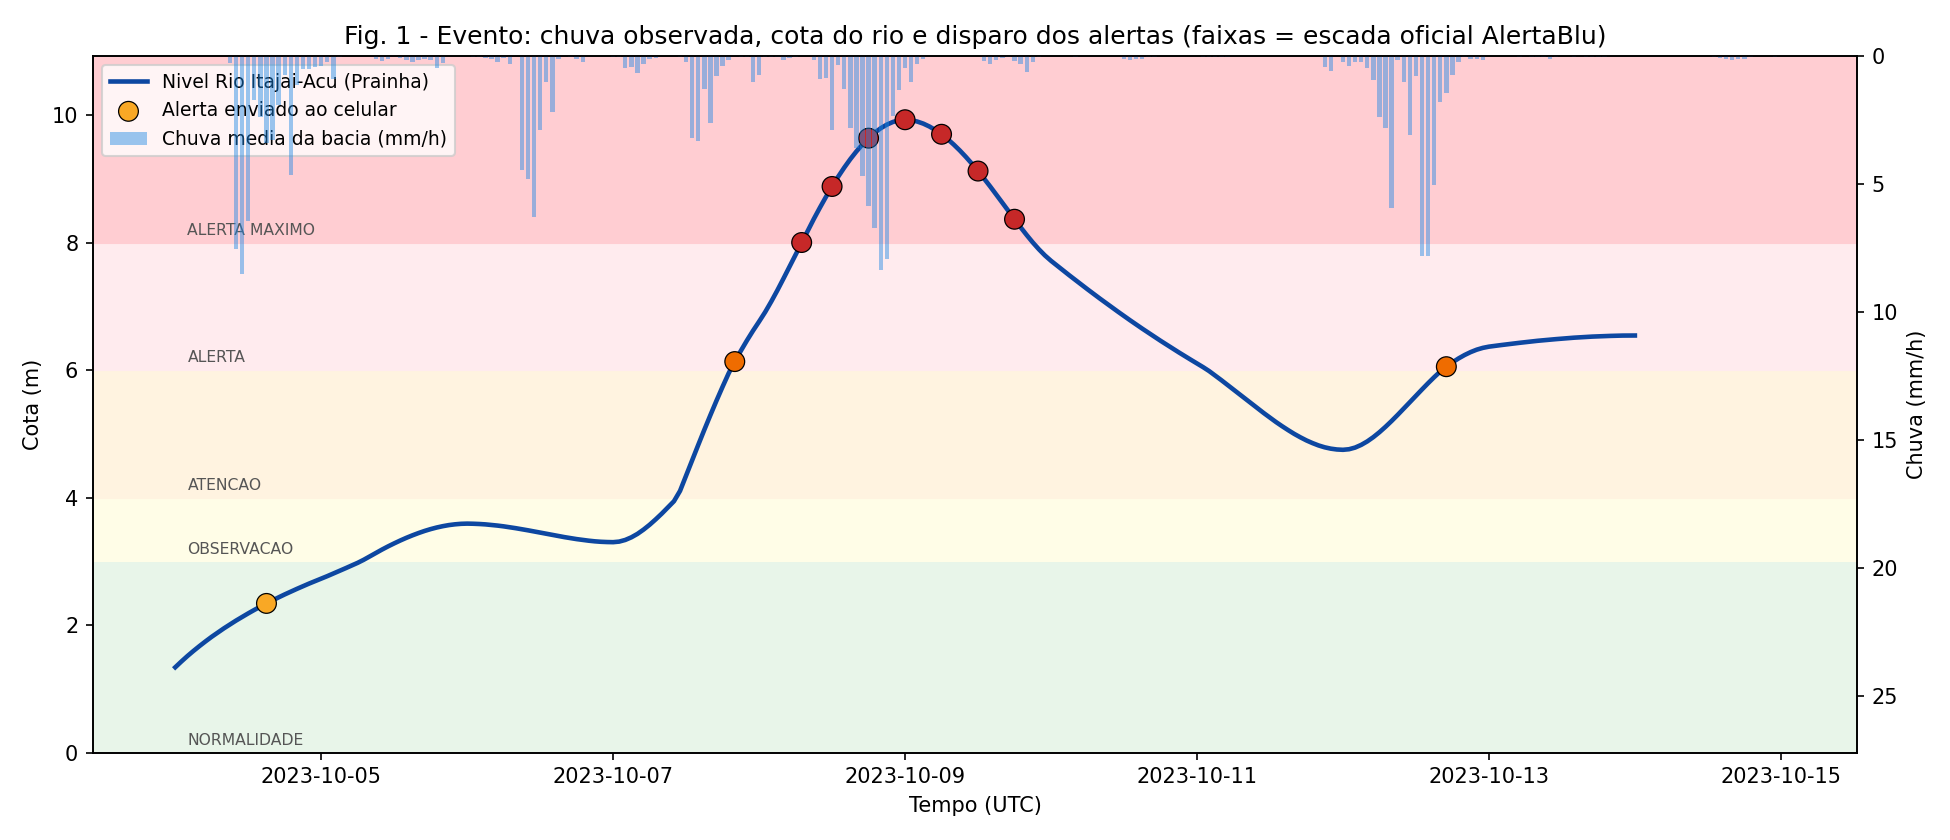

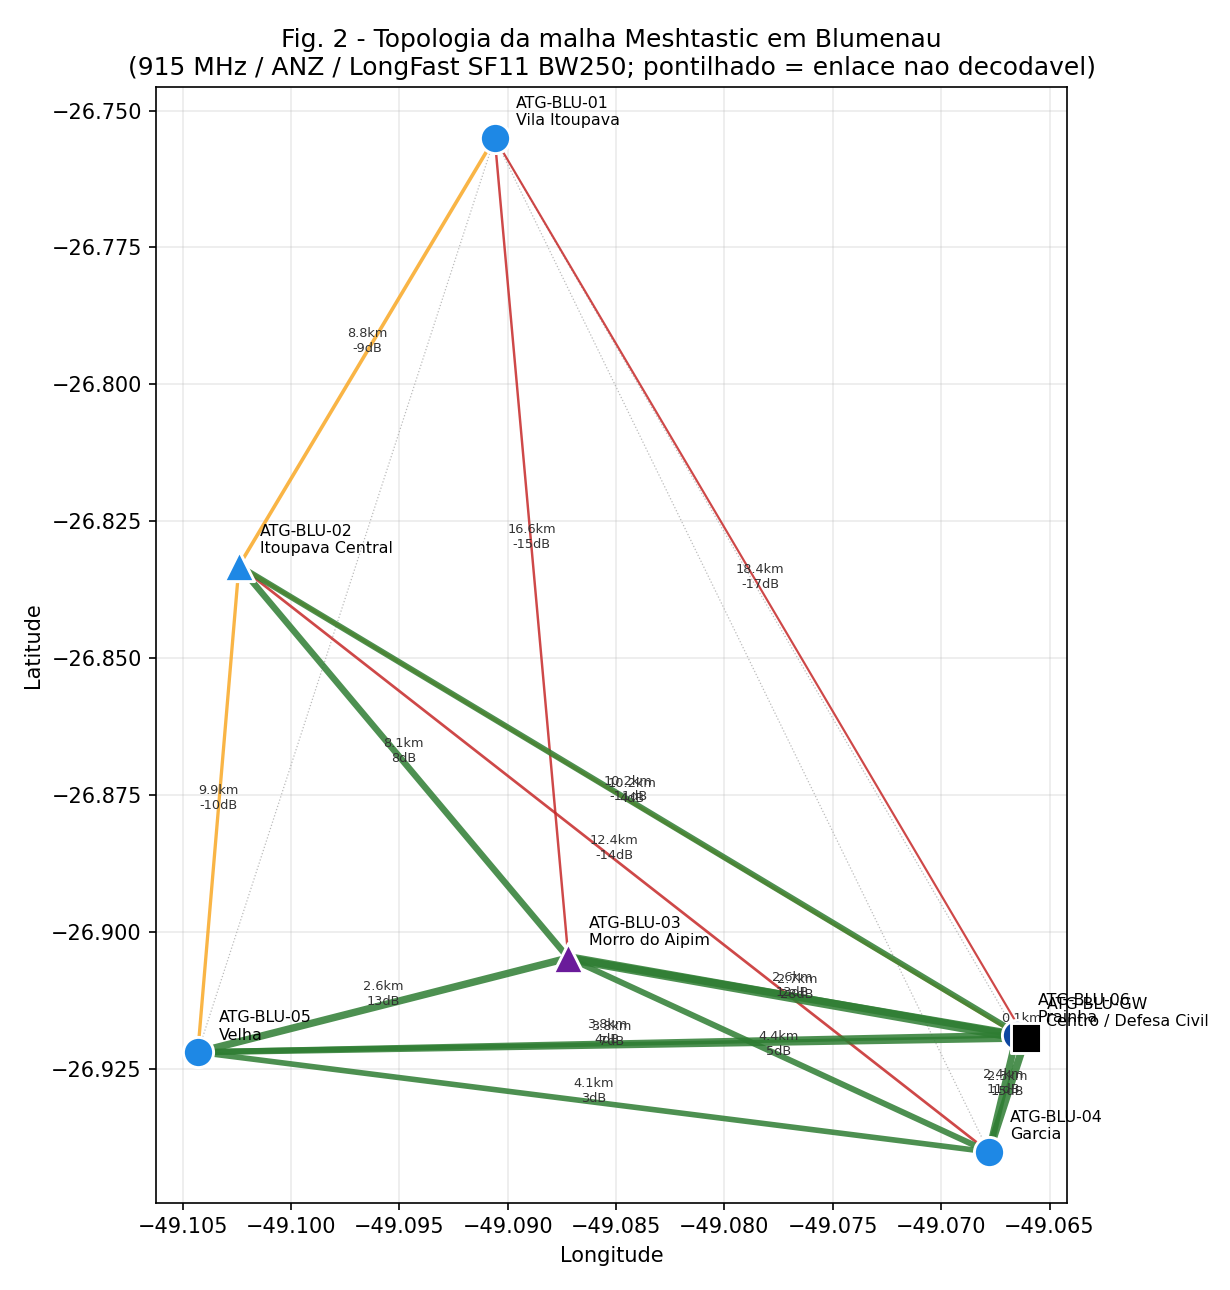

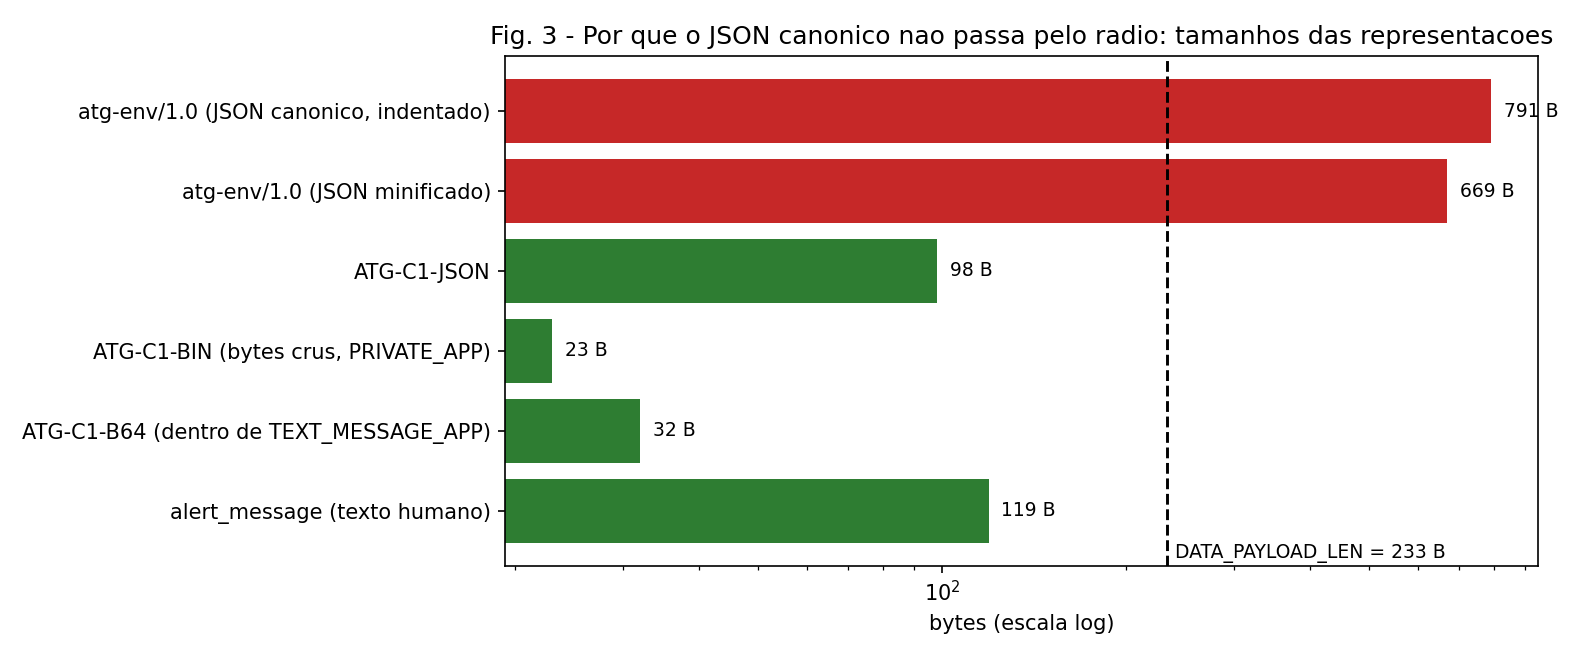

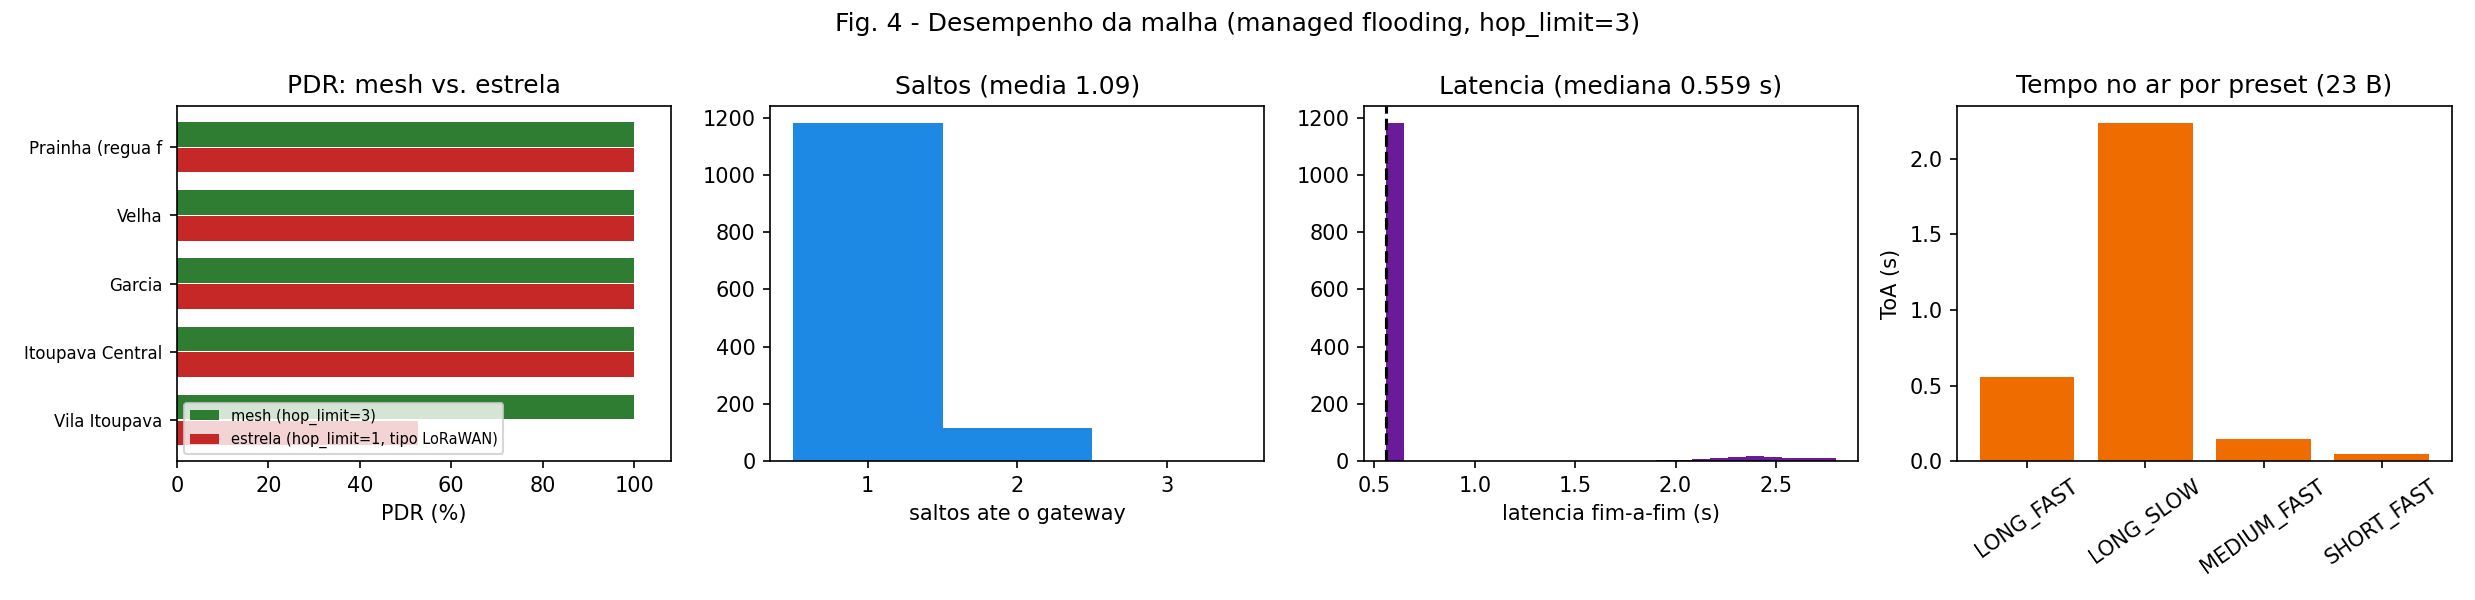

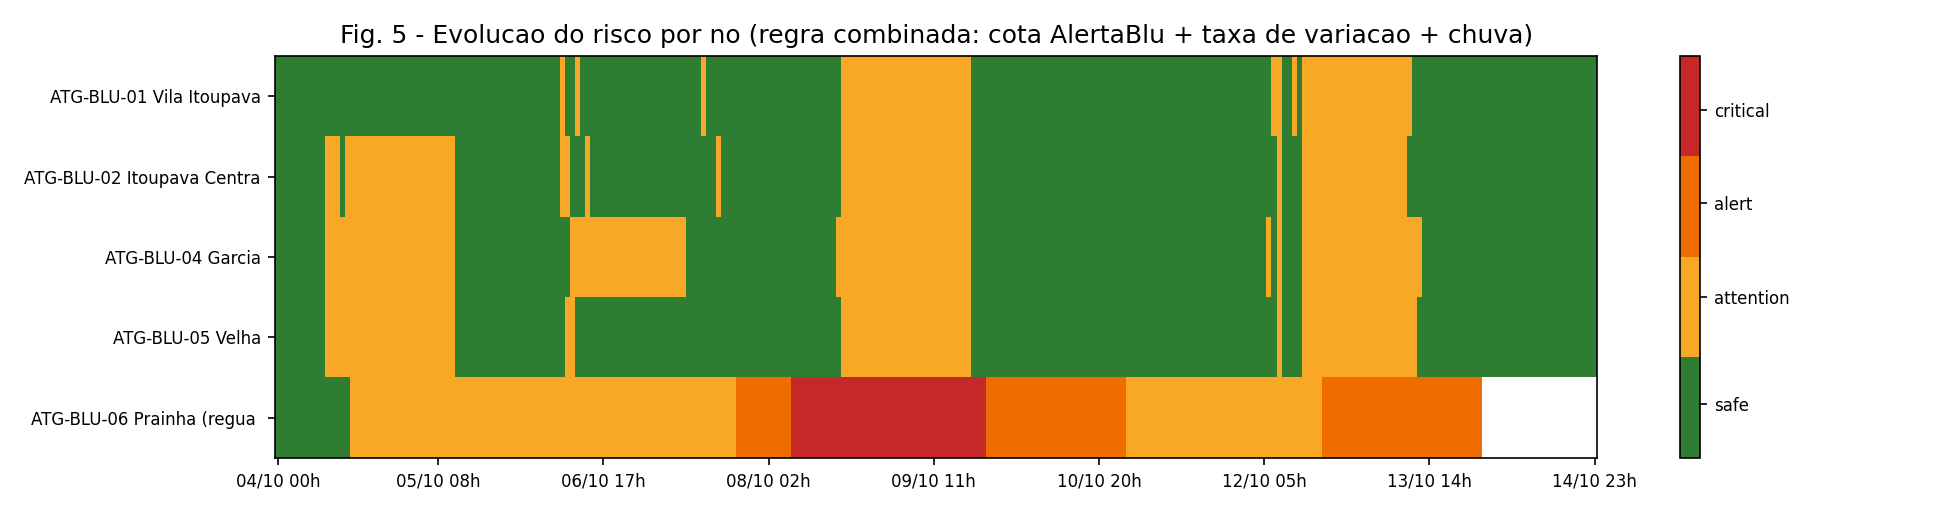

In [17]:
from IPython.display import Image, display

for f in ["fig1_hidrograma_alertas", "fig2_topologia_mesh", "fig3_tamanhos_payload",
          "fig4_metricas_mesh", "fig5_timeline_risco"]:
    display(Image(f"outputs/figures/{f}.png"))

## 11. Conclusão

1. **O JSON legível não cabe no rádio.** 665 B → 23 B com o ATG-C1. Foi a restrição que
   moldou todo o projeto.
2. **O mesh não é enfeite.** O nó de Vila Itoupava (18,4 km) entrega 54,2% em topologia
   estrela e 100% em mesh. É o argumento quantitativo para Meshtastic em vez de LoRaWAN aqui.
3. **A cota sozinha alerta tarde.** Cota + taxa de variação + chuva, com a escada oficial
   da Defesa Civil de Blumenau.

**Limitações:** nenhuma placa foi ligada; a cota é derivada da vazão GloFAS por mapeamento
de percentis (não é curva-chave); ERA5-Land subestima picos convectivos; o Meshtastic não
protege contra replay.

Detalhes, referências e próximos passos: `README.md`.

In [18]:
!zip -qr outputs.zip outputs data/raw
from google.colab import files
files.download("outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>